# LEGACY — монолитный All Metrics

Ноутбук сохранен вместе со старыми outputs только как история. Для новых запусков используйте `01_TargetDefinitionAndMetrics.ipynb`, `02_BalancedCausalPath.ipynb` и `03_CausalRepair.ipynb`.

**Target выбирается до атаки:** самый уверенный clean detection класса `person`. После наложения patch мы ищем detection того же человека по `IoU >= 0.5`. Primary success — target больше не детектируется при рабочем `confidence >= 0.25`.

Старое определение `max_person_conf(clean) - max_person_conf(patched) > 0.3` сохраняется только как `legacy_success`. Смена глобального winner, другой winner и исчезновение всех person detections являются отдельными outcomes, а не частью определения success.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

cwd = Path.cwd().resolve()
REPO_ROOT = next((p for p in [cwd, *cwd.parents] if (p / 'new_experiments').exists()), None)
if REPO_ROOT is None:
    raise RuntimeError('Run this notebook from inside PatchSuccessResearch.')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from CandidateRoutingAndAttackPath import load_experiment
from CandidateRoutingAndAttackPath.target_instance_metrics import (
    TargetInstanceConfig,
    build_target_instance_labels,
    evaluate_attack_path_metrics,
    evaluate_candidate_routing_metrics,
    load_target_labels,
    reevaluate_historical_detector_metrics,
)

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
plt.rcParams['figure.dpi'] = 110
print('repo:', REPO_ROOT)

repo: /Users/ashentide/PycharmProjects/PatchSuccessResearch


## 1. Зафиксированное определение target и success

In [2]:
OUTPUT_DIR = REPO_ROOT / 'CandidateRoutingAndAttackPath' / 'outputs' / 'target_instance_all_metrics'
TRACE_DB = REPO_ROOT / 'CandidateRoutingAndAttackPath' / 'outputs' / 'candidate_trace_b3c25981c3ad62d5' / 'candidate_tracing.sqlite'
ATTACK_PATH_DB = REPO_ROOT / 'CandidateRoutingAndAttackPath' / 'outputs' / 'attack_path_5ef23878fe1dfaea' / 'attack_path.sqlite'
LEGACY_QUALITY = REPO_ROOT / 'ClassifierDetectorExperiments' / 'outputs' / 'all_metrics_quality.csv'

MATCH_IOU = 0.50
DETECTION_CONF = 0.25
INFERENCE_CONF = 0.01
TARGET_SUPPRESSION_DELTA = 0.30
BATCH_SIZE = 16
MAX_EXAMPLES = None  # полный balanced attack cache: 6000
FORCE_LABEL_REBUILD = False
FORCE_METRIC_REBUILD = False

definition = pd.Series({
    'target_policy': 'highest-confidence clean person, selected before patch',
    'match_rule': f'patched person IoU >= {MATCH_IOU}',
    'primary_success': f'no matched target with confidence >= {DETECTION_CONF}',
    'continuous_outcome': 'clean target confidence - matched patched target confidence',
    'legacy_only': f'global max-person confidence drop > {TARGET_SUPPRESSION_DELTA}',
}).to_frame('fixed definition')
display(definition)

,fixed definition
target_policy,"highest-confidence clean person, selected befo..."
match_rule,patched person IoU >= 0.5
primary_success,no matched target with confidence >= 0.25
continuous_outcome,clean target confidence - matched patched targ...
legacy_only,global max-person confidence drop > 0.3


In [3]:
exp, attack_cache_path = load_experiment(
    repo_root=REPO_ROOT, prefer_dataset='COCO_people', prefer_device='mps', require_device=False,
)
cache = exp.get_cache()
print('attack cache:', attack_cache_path)
print('examples:', len(cache.examples))
print('device:', exp.config.attack.device)

attack cache: /Users/ashentide/PycharmProjects/PatchSuccessResearch/new_experiments/new_experiments/outputs/patch_success_analysis/cache/attack_pool_d60ec9ed15ee6591.pkl
examples: 6000
device: mps


## 2. Identity-aware разметка

Первый запуск выполняет только patched inference и сохраняет resumable SQLite. Повторный запуск читает готовую разметку. Full feature caches не пересчитываются.

In [4]:
label_config = TargetInstanceConfig(
    output_dir=str(OUTPUT_DIR), match_iou=MATCH_IOU, detection_conf=DETECTION_CONF,
    inference_conf=INFERENCE_CONF, target_suppression_delta=TARGET_SUPPRESSION_DELTA,
    batch_size=BATCH_SIZE, max_examples=MAX_EXAMPLES, progress=True,
)
target_result = build_target_instance_labels(exp, label_config, force=FORCE_LABEL_REBUILD)
labels = load_target_labels(target_result)
print(target_result.digest_path.read_text())
print('labels:', target_result.labels_path)
display(labels.head())

target-instance labeling: 0img [00:00, ?img/s]

# Target-instance labels

- rows: 6000
- baseline-eligible targets: 5985
- primary target-hidden rate: 0.346
- legacy max-confidence success rate: 0.501
- legacy/target label agreement: 0.730

Primary success is target_hidden. legacy_success is retained only for comparison.

labels: /Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/outputs/target_instance_all_metrics/target_instance_bc9b647edb5cdec7/target_instance_labels.csv


,image_key,path,example_id,legacy_success,legacy_drop,target_policy,target_class_id,target_clean_conf,target_clean_x1,target_clean_y1,target_clean_x2,target_clean_y2,target_eligible,match_iou_threshold,detection_conf_threshold,target_match_iou,target_patched_conf,target_conf_drop,target_detected,target_hidden,target_suppressed_0p3,matched_x1,matched_y1,matched_x2,matched_y2,patched_person_count,patched_global_conf,patched_winner_iou_target,patched_winner_is_target,patched_winner_x1,patched_winner_y1,patched_winner_x2,patched_winner_y2,outcome,error
0,05508_train2017_image554566_ann197605.jpg,/Users/ashentide/PycharmProjects/PatchSuccessR...,7b1c5ce4f30e936c,1,0.607583,clean_top_person_pre_attack,0,0.923309,59.259460,74.711182,349.360687,634.976135,1,0.5,0.25,0.739453,0.051750,0.871558,0,1,1,1.876953,139.846191,349.051147,625.720520,2,0.315727,0.437536,0,0.414551,117.858887,638.657227,634.013428,target_hidden_non_target_winner,NaN
1,00385_train2017_image422725_ann455624.jpg,/Users/ashentide/PycharmProjects/PatchSuccessR...,4d39ee7b55a89023,0,0.196287,clean_top_person_pre_attack,0,0.944681,160.707611,40.873535,473.469452,602.080933,1,0.5,0.25,0.663647,0.748393,0.196288,1,0,0,6.426514,38.689209,474.125305,598.961731,2,0.748393,0.663647,1,6.426514,38.689209,474.125305,598.961731,target_visible_target_winner,NaN
2,02382_train2017_image127990_ann430340.jpg,/Users/ashentide/PycharmProjects/PatchSuccessR...,131b11ae40741ed5,0,0.013551,clean_top_person_pre_attack,0,0.890149,177.456482,49.304260,455.679688,571.959290,1,0.5,0.25,0.975852,0.876598,0.013551,1,0,0,180.669861,50.901733,454.830811,568.492798,2,0.876598,0.975852,1,180.669861,50.901733,454.830811,568.492798,target_visible_target_winner,NaN
3,04290_train2017_image466491_ann466576.jpg,/Users/ashentide/PycharmProjects/PatchSuccessR...,f8a053f4548e07fb,0,0.293553,clean_top_person_pre_attack,0,0.855741,41.134766,67.978577,568.097046,621.227173,1,0.5,0.25,0.814230,0.562188,0.293553,1,0,0,0.000000,60.452759,628.898376,629.793823,3,0.562188,0.814230,1,0.000000,60.452759,628.898376,629.793823,target_visible_target_winner,NaN
4,00070_train2017_image8872_ann464695.jpg,/Users/ashentide/PycharmProjects/PatchSuccessR...,04a01a5f82c665d5,0,0.191687,clean_top_person_pre_attack,0,0.887930,216.201981,44.168335,417.596863,611.860168,1,0.5,0.25,0.000000,0.000000,0.887930,0,1,1,NaN,NaN,NaN,NaN,0,0.000000,0.000000,0,NaN,NaN,NaN,NaN,target_hidden_no_person,NaN


eligible: 5985 / 6000


primary_success,target hidden,target visible,All
legacy_success_bool,,,
legacy fail,343,2642,2985
legacy success,1726,1274,3000
All,2069,3916,5985


,n
outcome,
target_visible_target_winner,3624
target_hidden_non_target_winner,2003
target_visible_non_target_winner,292
target_hidden_no_person,66


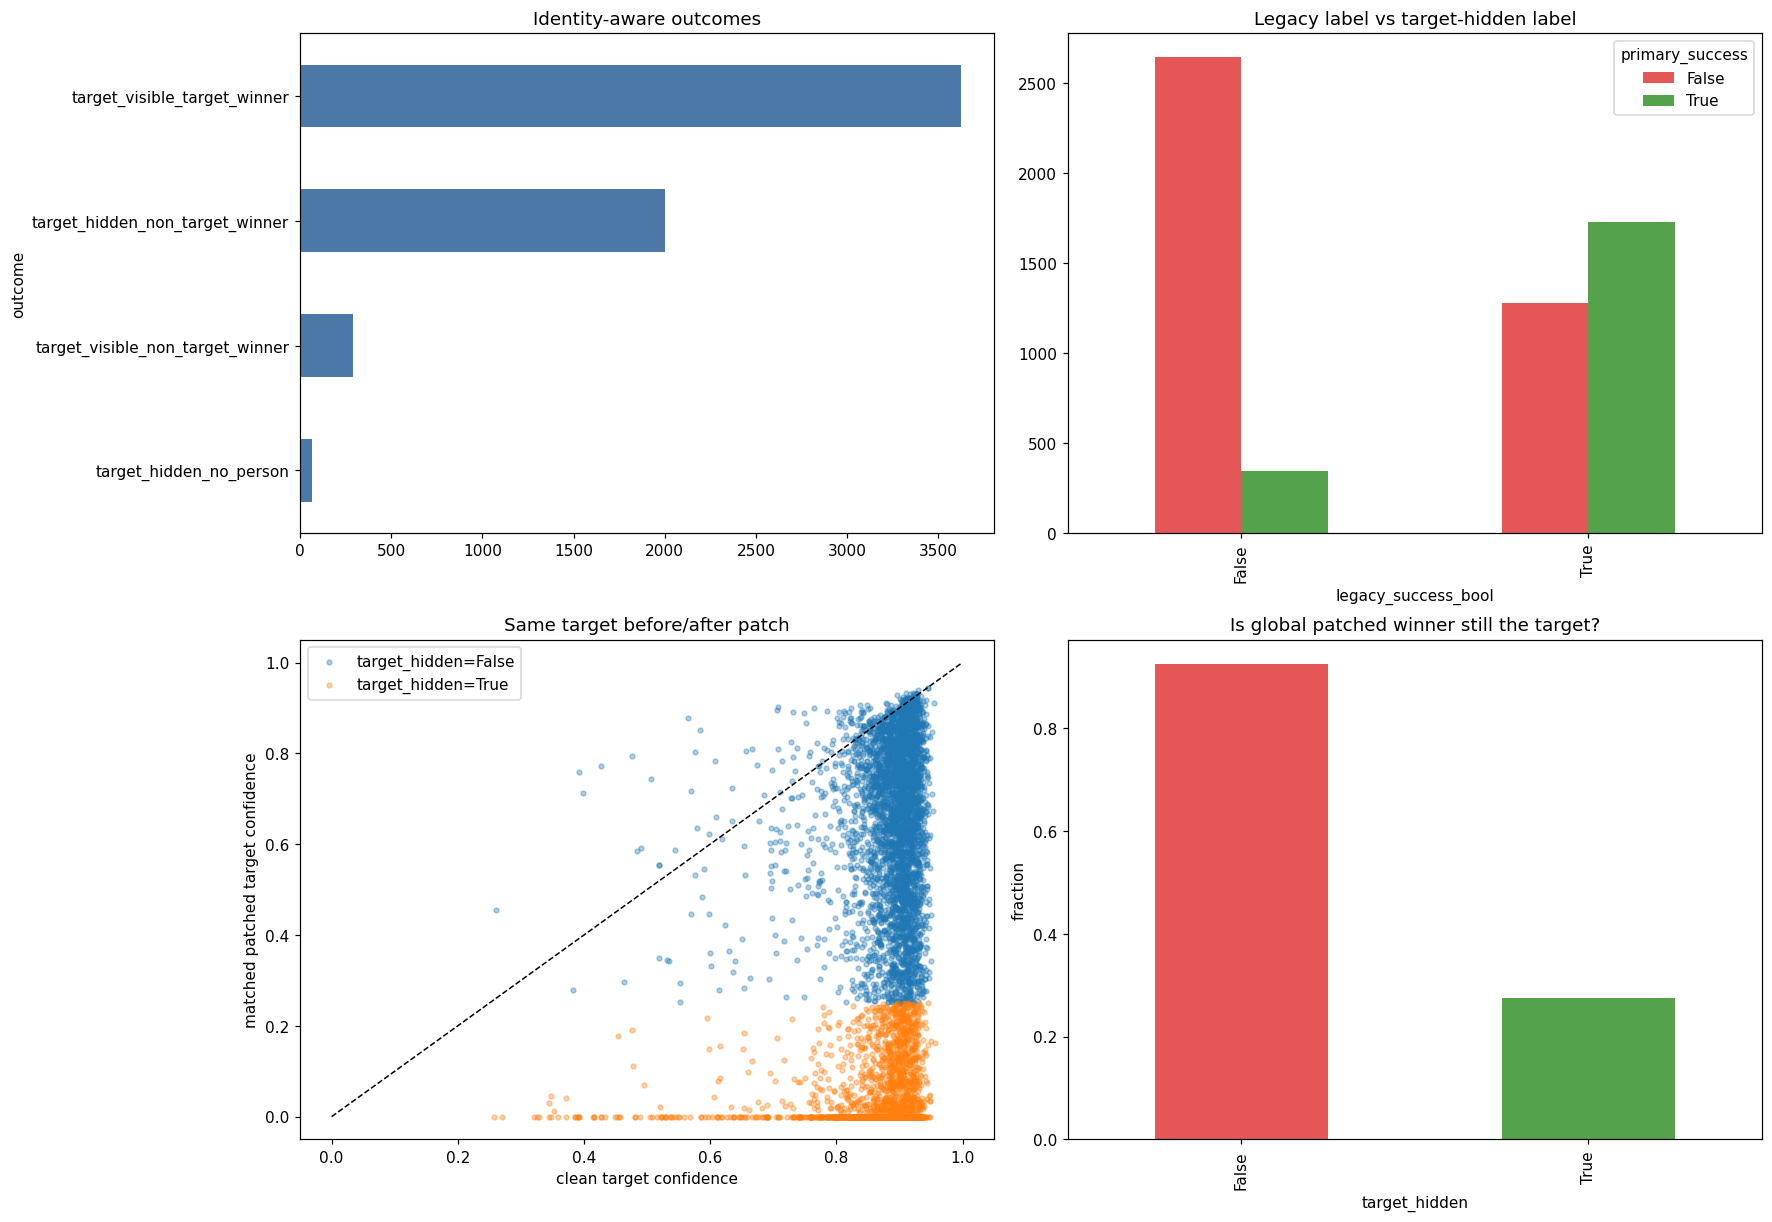

In [5]:
eligible = labels[labels.target_eligible.eq(1) & labels.target_hidden.notna()].copy()
eligible['primary_success'] = eligible.target_hidden.astype(bool)
eligible['legacy_success_bool'] = eligible.legacy_success.astype(bool)

print('eligible:', len(eligible), '/', len(labels))
display(pd.crosstab(
    eligible.legacy_success_bool.map({False: 'legacy fail', True: 'legacy success'}),
    eligible.primary_success.map({False: 'target visible', True: 'target hidden'}),
    margins=True,
))
display(eligible.outcome.value_counts().rename_axis('outcome').to_frame('n'))

fig, axes = plt.subplots(2, 2, figsize=(16, 11), constrained_layout=True)
eligible.outcome.value_counts().sort_values().plot.barh(ax=axes[0, 0], color='#4c78a8')
axes[0, 0].set_title('Identity-aware outcomes')
pd.crosstab(eligible.legacy_success_bool, eligible.primary_success).plot.bar(ax=axes[0, 1], color=['#e45756', '#54a24b'])
axes[0, 1].set_title('Legacy label vs target-hidden label')
for success, group in eligible.groupby('primary_success'):
    axes[1, 0].scatter(group.target_clean_conf, group.target_patched_conf, s=10, alpha=.35, label=f'target_hidden={success}')
axes[1, 0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1, 0].set(xlabel='clean target confidence', ylabel='matched patched target confidence', title='Same target before/after patch')
axes[1, 0].legend()
eligible.groupby('primary_success').patched_winner_is_target.mean().plot.bar(ax=axes[1, 1], color=['#e45756', '#54a24b'])
axes[1, 1].set(title='Is global patched winner still the target?', ylabel='fraction', xlabel='target_hidden')
plt.show()

### Визуальная проверка разметки отдельных людей

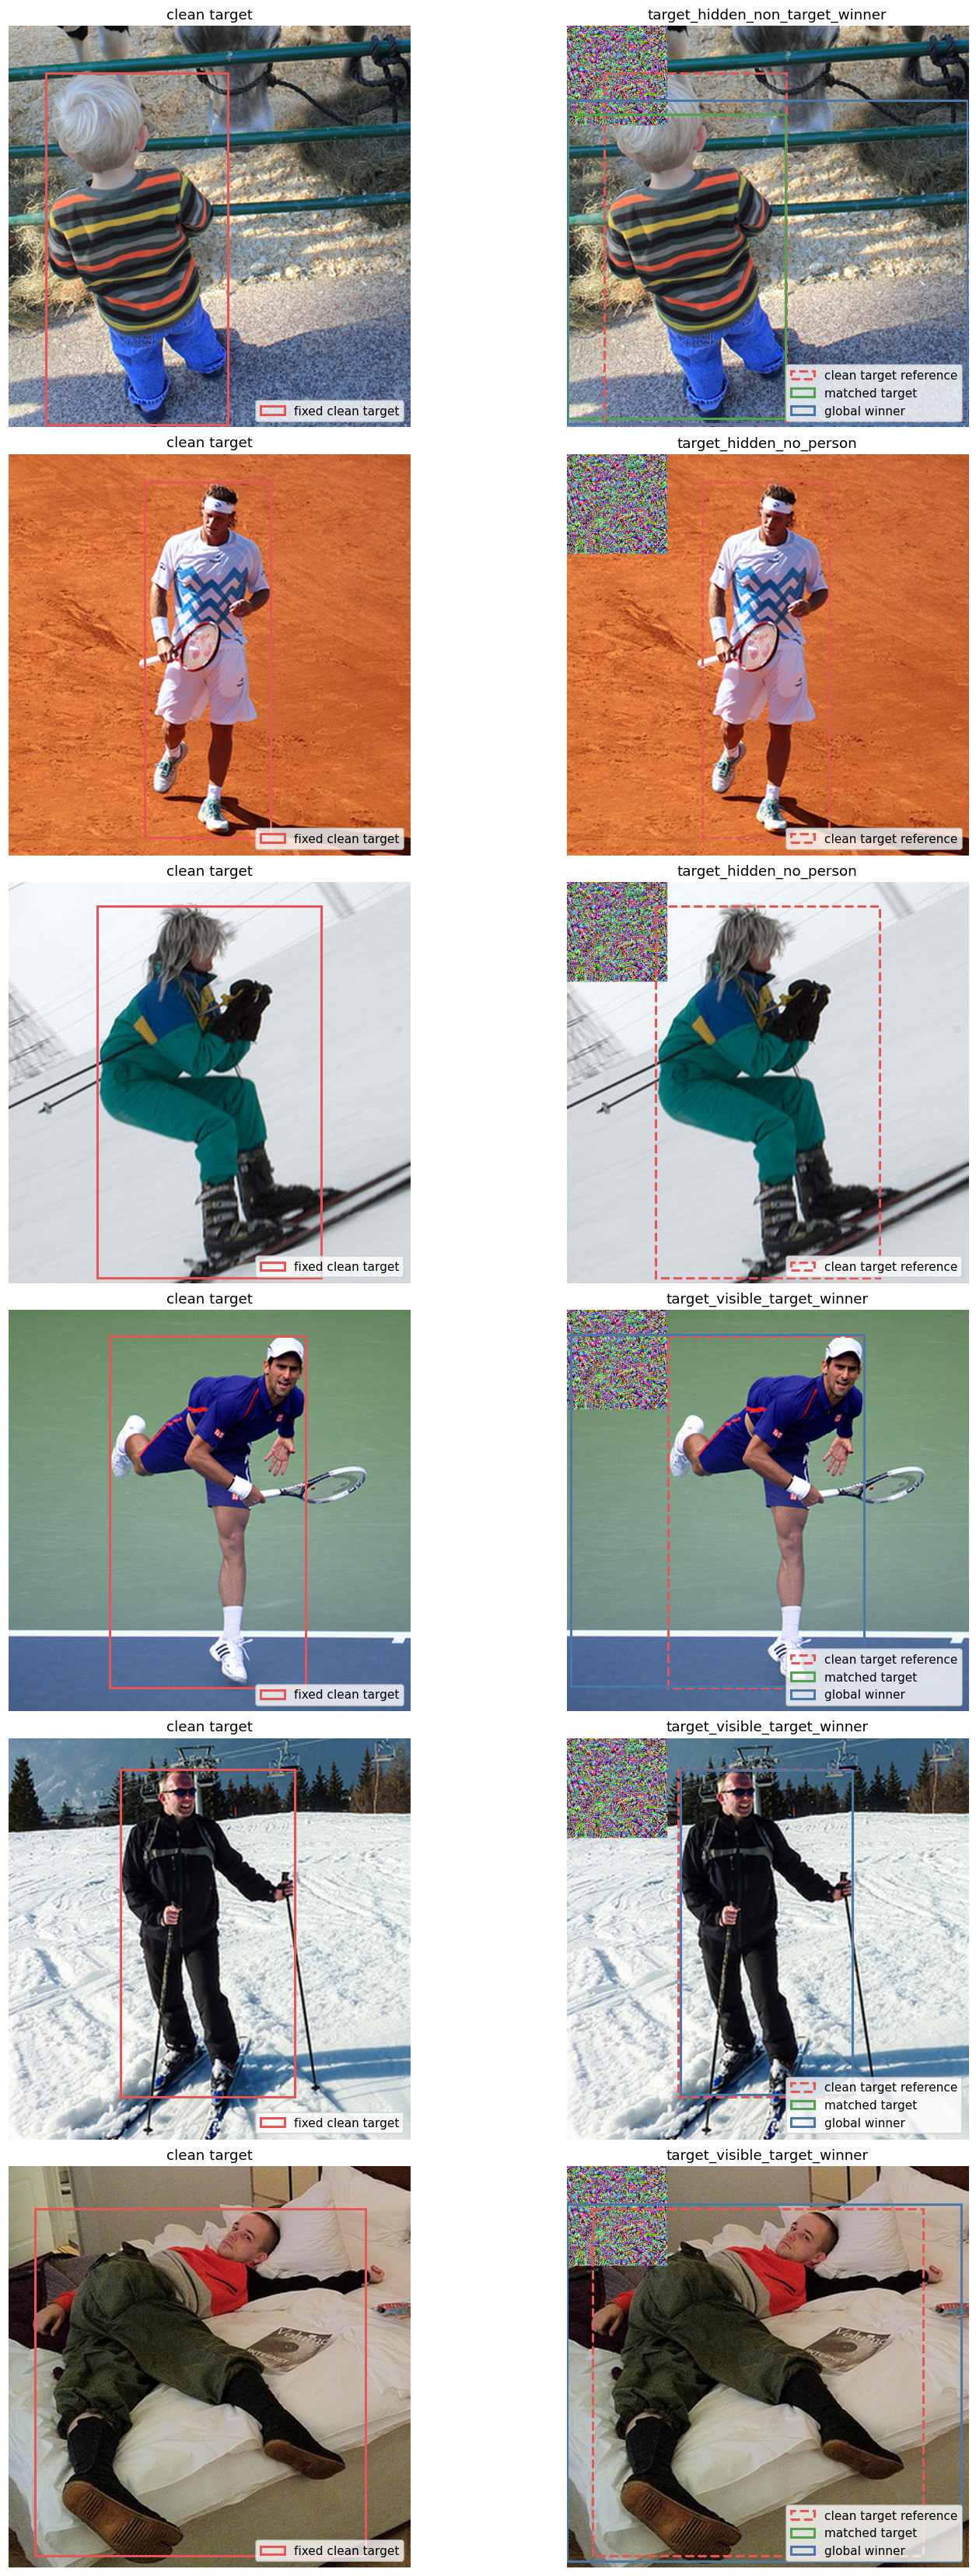

In [6]:
from matplotlib.patches import Rectangle

cache_by_key = {Path(item.path).name: item for item in cache.examples}
chosen = pd.concat([
    eligible[eligible.primary_success].head(3),
    eligible[~eligible.primary_success].head(3),
]).drop_duplicates('image_key')

fig, axes = plt.subplots(len(chosen), 2, figsize=(13, 5 * len(chosen)), constrained_layout=True)
if len(chosen) == 1:
    axes = np.asarray([axes])
for row_idx, row in enumerate(chosen.itertuples(index=False)):
    example = cache_by_key[row.image_key]
    clean, patched, _ = exp._images_for_example(example)
    for ax, image, title in [(axes[row_idx, 0], clean, 'clean target'), (axes[row_idx, 1], patched, row.outcome)]:
        ax.imshow(image); ax.set_title(title); ax.axis('off')
    tx1, ty1, tx2, ty2 = row.target_clean_x1, row.target_clean_y1, row.target_clean_x2, row.target_clean_y2
    axes[row_idx, 0].add_patch(Rectangle((tx1, ty1), tx2-tx1, ty2-ty1, fill=False, edgecolor='#e45756', linewidth=2, label='fixed clean target'))
    axes[row_idx, 1].add_patch(Rectangle((tx1, ty1), tx2-tx1, ty2-ty1, fill=False, edgecolor='#e45756', linewidth=2, linestyle='--', label='clean target reference'))
    if pd.notna(row.matched_x1):
        axes[row_idx, 1].add_patch(Rectangle((row.matched_x1, row.matched_y1), row.matched_x2-row.matched_x1, row.matched_y2-row.matched_y1, fill=False, edgecolor='#54a24b', linewidth=2, label='matched target'))
    if pd.notna(row.patched_winner_x1):
        axes[row_idx, 1].add_patch(Rectangle((row.patched_winner_x1, row.patched_winner_y1), row.patched_winner_x2-row.patched_winner_x1, row.patched_winner_y2-row.patched_winner_y1, fill=False, edgecolor='#4c78a8', linewidth=2, label='global winner'))
    axes[row_idx, 0].legend(loc='lower right'); axes[row_idx, 1].legend(loc='lower right')
plt.show()

## 3. Переоценка исторических detector-метрик

Используются существующие feature/metric pickle-кэши. Меняется только label и непрерывный target outcome; скрытого rebuild активаций здесь нет.

In [7]:
historical = reevaluate_historical_detector_metrics(
    labels, legacy_quality_path=LEGACY_QUALITY, output_dir=OUTPUT_DIR, force=FORCE_METRIC_REBUILD,
)
quality = historical['quality']
regression = historical['regression']
coverage = historical['coverage']
print('loaded from compact target cache:', historical['loaded_from_cache'])
print('quality:', quality.shape, 'regression:', regression.shape)
display(coverage)
display(quality.head(30))

loaded from compact target cache: True
quality: (7581, 29) regression: (7581, 16)


,cache_file,status,source_rows,matched_rows,matched_unique_images
0,/Users/ashentide/PycharmProjects/PatchSuccessR...,ok,3998,3348,1674
1,/Users/ashentide/PycharmProjects/PatchSuccessR...,ok,3998,3348,1674
2,/Users/ashentide/PycharmProjects/PatchSuccessR...,ok,23988,20088,1674
3,/Users/ashentide/PycharmProjects/PatchSuccessR...,ok,3998,3348,1674
4,/Users/ashentide/PycharmProjects/PatchSuccessR...,ok,3998,3348,1674
5,/Users/ashentide/PycharmProjects/PatchSuccessR...,ok,15992,13392,1674
6,/Users/ashentide/PycharmProjects/PatchSuccessR...,ok,1999,1674,1674
7,/Users/ashentide/PycharmProjects/PatchSuccessR...,ok,5646,4717,4717
8,/Users/ashentide/PycharmProjects/PatchSuccessR...,ok,5646,4717,4717
9,/Users/ashentide/PycharmProjects/PatchSuccessR...,ok,5646,4717,4717


,source,experiment,metric,n,n_success,n_failure,roc_auc,cache_file,legacy_roc_auc,family,top_percent,aggregate,cov_method,sigma,cov_group,best_f1,best_precision,best_recall,best_threshold,best_direction,best_accuracy,best_balanced_accuracy,balanced_precision,balanced_recall,balanced_specificity,balanced_f1,balanced_accuracy_plain,balanced_threshold,balanced_direction
0,detector_target_instance,psnr,psnr_top8p1_importance_sum,4717,1463,3254,0.145715,/Users/ashentide/PycharmProjects/PatchSuccessR...,0.302717,psnr_percent_sweep,8.1,sum,NaN,NaN,NaN,0.687719,0.600920,0.803828,114687.157134,-1,0.773585,0.781908,0.600920,0.803828,0.759988,0.687719,0.773585,114687.157134,-1
1,detector_target_instance,psnr,psnr_top8p1_importance_mean,4717,1463,3254,0.145715,/Users/ashentide/PycharmProjects/PatchSuccessR...,0.302717,psnr_percent_sweep,8.1,mean,NaN,NaN,NaN,0.687719,0.600920,0.803828,6.913446,-1,0.773585,0.781908,0.600920,0.803828,0.759988,0.687719,0.773585,6.913446,-1
2,detector_target_instance,psnr,psnr_top8p1_importance_sum,4717,1463,3254,0.145715,/Users/ashentide/PycharmProjects/PatchSuccessR...,0.302717,psnr_percent_sweep,8.1,sum,NaN,NaN,NaN,0.687719,0.600920,0.803828,114687.157134,-1,0.773585,0.781908,0.600920,0.803828,0.759988,0.687719,0.773585,114687.157134,-1
3,detector_target_instance,psnr,psnr_top8p1_importance_mean,4717,1463,3254,0.145715,/Users/ashentide/PycharmProjects/PatchSuccessR...,0.302717,psnr_percent_sweep,8.1,mean,NaN,NaN,NaN,0.687719,0.600920,0.803828,6.913446,-1,0.773585,0.781908,0.600920,0.803828,0.759988,0.687719,0.773585,6.913446,-1
4,detector_target_instance,psnr,psnr_top8p7_importance_sum,4717,1463,3254,0.144820,/Users/ashentide/PycharmProjects/PatchSuccessR...,0.301132,psnr_percent_sweep,8.7,sum,NaN,NaN,NaN,0.687445,0.603199,0.799043,123412.498035,-1,0.774645,0.781359,0.603199,0.799043,0.763675,0.687445,0.774645,123412.498035,-1
5,detector_target_instance,psnr,psnr_top8p7_importance_mean,4717,1463,3254,0.144820,/Users/ashentide/PycharmProjects/PatchSuccessR...,0.301132,psnr_percent_sweep,8.7,mean,NaN,NaN,NaN,0.687445,0.603199,0.799043,6.926282,-1,0.774645,0.781359,0.603199,0.799043,0.763675,0.687445,0.774645,6.926282,-1
6,detector_target_instance,psnr,psnr_top8p7_importance_sum,4717,1463,3254,0.144820,/Users/ashentide/PycharmProjects/PatchSuccessR...,0.301132,psnr_percent_sweep,8.7,sum,NaN,NaN,NaN,0.687445,0.603199,0.799043,123412.498035,-1,0.774645,0.781359,0.603199,0.799043,0.763675,0.687445,0.774645,123412.498035,-1
7,detector_target_instance,psnr,psnr_top8p7_importance_mean,4717,1463,3254,0.144820,/Users/ashentide/PycharmProjects/PatchSuccessR...,0.301132,psnr_percent_sweep,8.7,mean,NaN,NaN,NaN,0.687445,0.603199,0.799043,6.926282,-1,0.774645,0.781359,0.603199,0.799043,0.763675,0.687445,0.774645,6.926282,-1
8,detector_target_instance,psnr,psnr_top7_importance_sum,4717,1463,3254,0.147280,/Users/ashentide/PycharmProjects/PatchSuccessR...,0.303250,psnr_percent_sweep,7.0,sum,NaN,NaN,NaN,0.683495,0.575163,0.842105,99171.020210,-1,0.758109,0.781225,0.575163,0.842105,0.720344,0.683495,0.758109,99171.020210,-1
9,detector_target_instance,psnr,psnr_top7_importance_mean,4717,1463,3254,0.147280,/Users/ashentide/PycharmProjects/PatchSuccessR...,0.303250,psnr_percent_sweep,7.0,mean,NaN,NaN,NaN,0.683495,0.575163,0.842105,6.917621,-1,0.758109,0.781225,0.575163,0.842105,0.720344,0.683495,0.758109,6.917621,-1


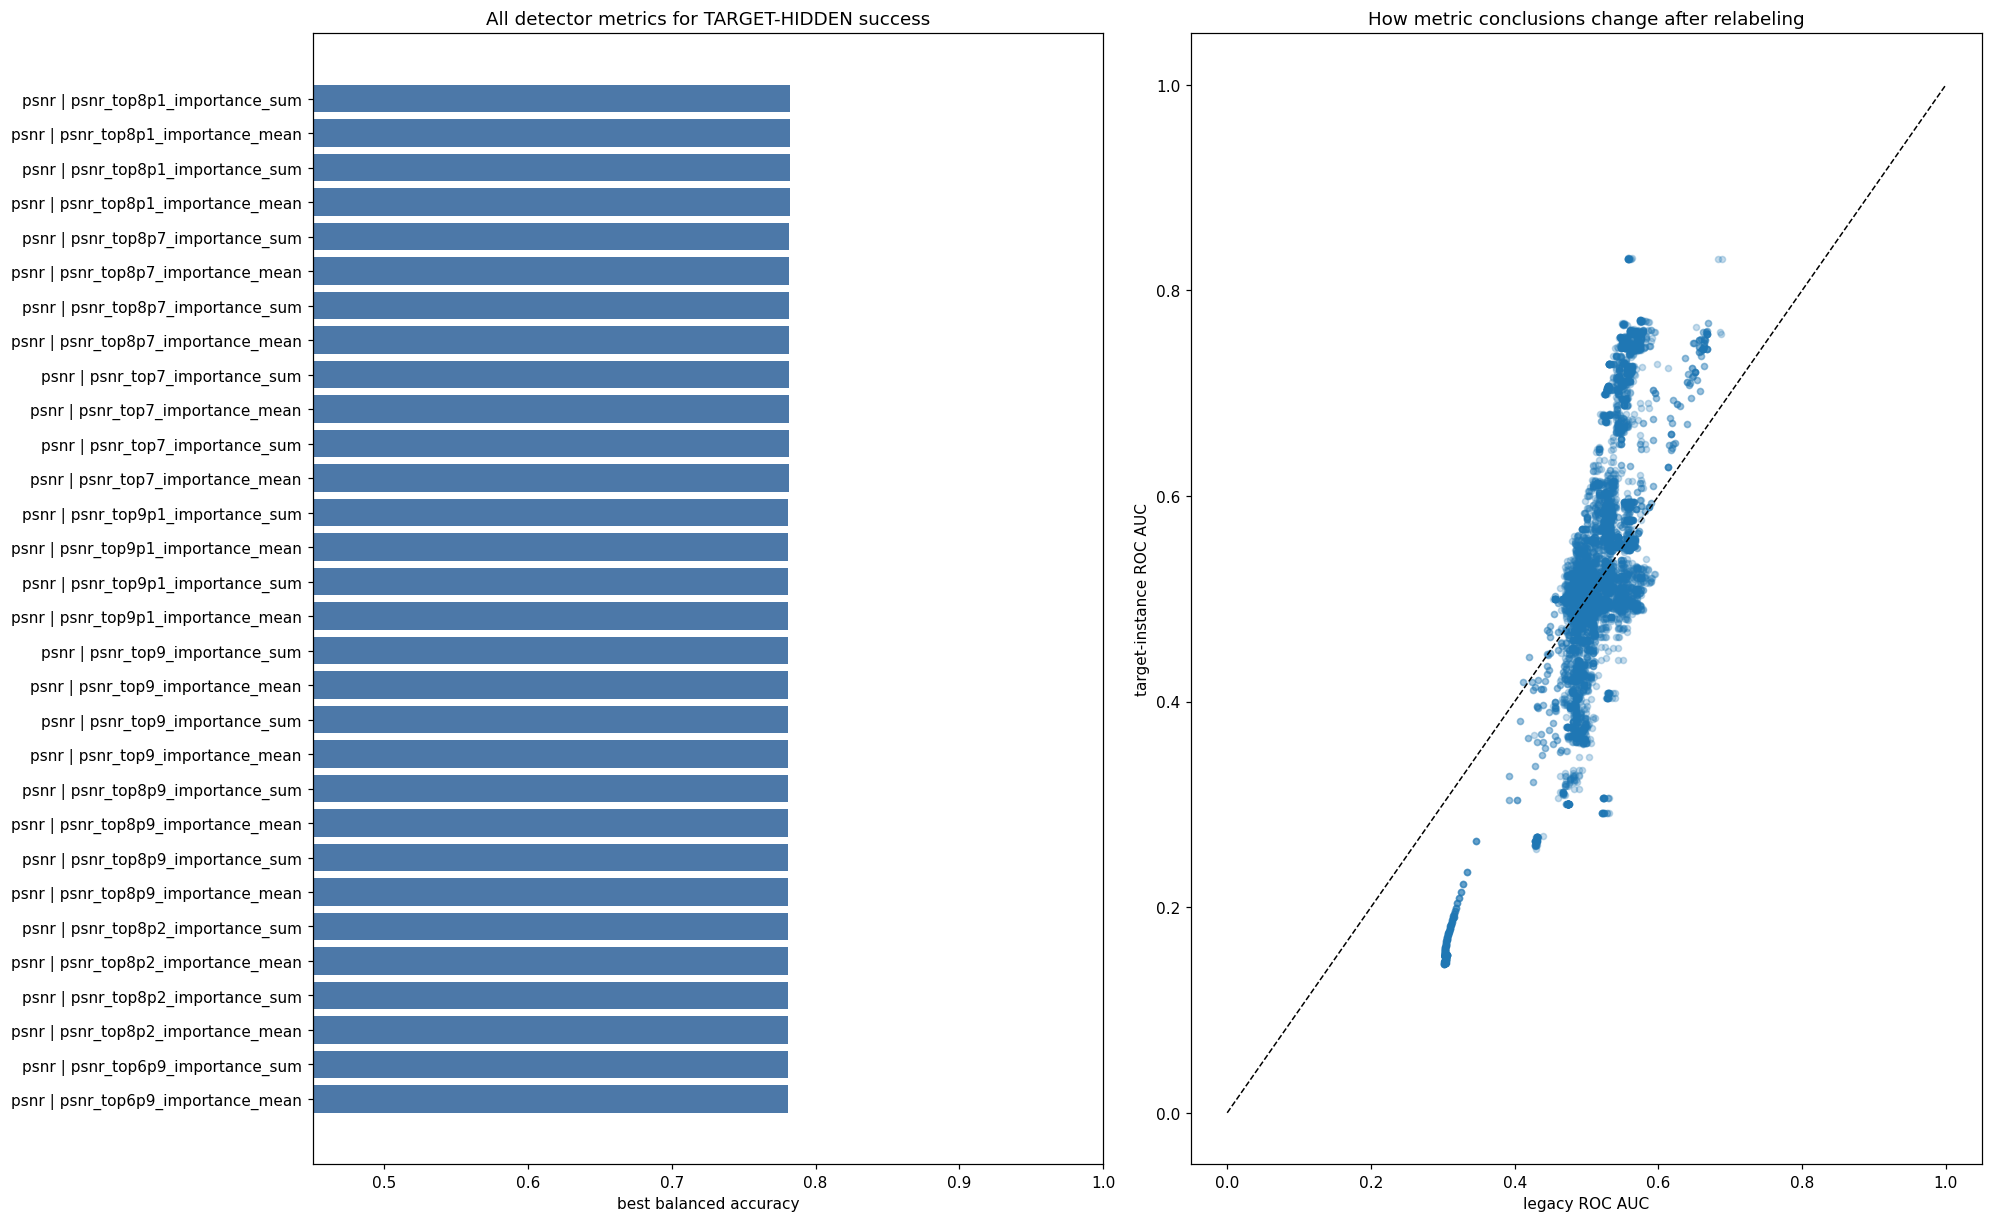

In [8]:
top = quality.sort_values(['best_balanced_accuracy', 'roc_auc'], ascending=False).head(30).copy()
top['label'] = top.experiment.astype(str) + ' | ' + top.metric.astype(str)
top['effective_auc'] = np.maximum(top.roc_auc, 1 - top.roc_auc)

fig, axes = plt.subplots(1, 2, figsize=(18, 11), constrained_layout=True)
axes[0].barh(np.arange(len(top)), top.best_balanced_accuracy, color='#4c78a8')
axes[0].set_yticks(np.arange(len(top)), top.label); axes[0].invert_yaxis(); axes[0].set_xlim(.45, 1)
axes[0].set_title('All detector metrics for TARGET-HIDDEN success')
axes[0].set_xlabel('best balanced accuracy')
axes[1].scatter(quality.legacy_roc_auc, quality.roc_auc, alpha=.25, s=16)
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set(xlabel='legacy ROC AUC', ylabel='target-instance ROC AUC', title='How metric conclusions change after relabeling')
plt.show()

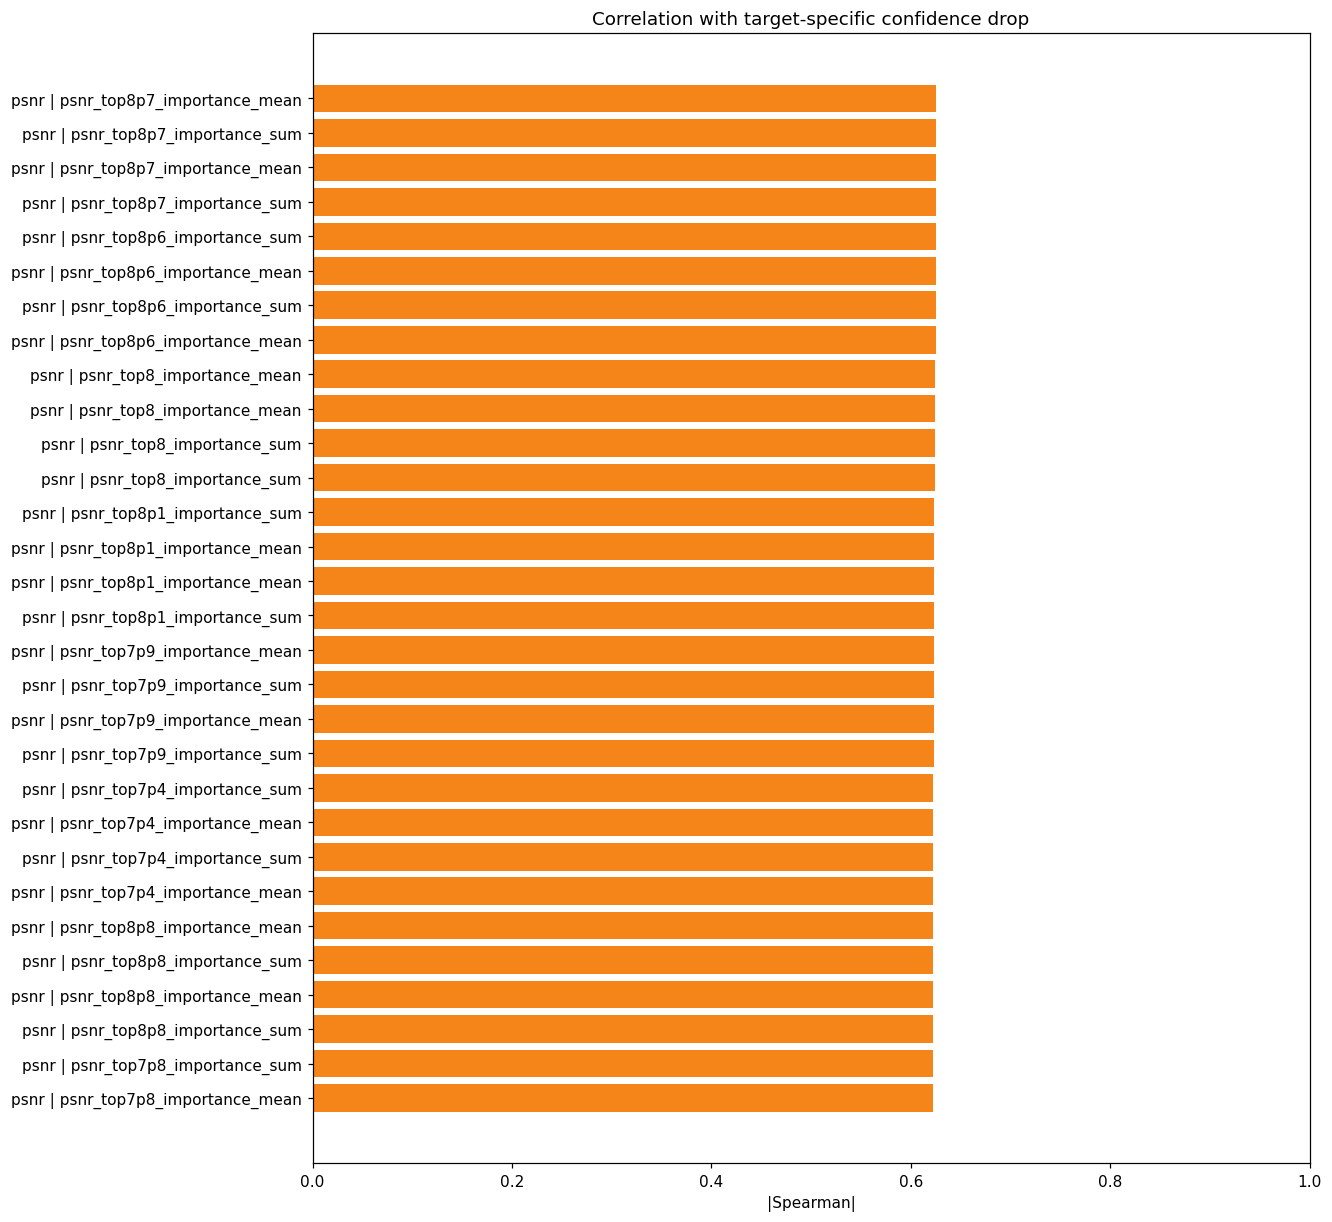

,source,experiment,metric,n,cache_file,family,top_percent,aggregate,cov_method,sigma,cov_group,pearson,spearman,abs_pearson,abs_spearman,main_score,label
0,detector_target_instance,psnr,psnr_top8p7_importance_mean,4717,/Users/ashentide/PycharmProjects/PatchSuccessR...,psnr_percent_sweep,8.7,mean,NaN,NaN,NaN,-0.603471,-0.625539,0.603471,0.625539,0.625539,psnr | psnr_top8p7_importance_mean
3,detector_target_instance,psnr,psnr_top8p7_importance_sum,4717,/Users/ashentide/PycharmProjects/PatchSuccessR...,psnr_percent_sweep,8.7,sum,NaN,NaN,NaN,-0.603471,-0.625539,0.603471,0.625539,0.625539,psnr | psnr_top8p7_importance_sum
1,detector_target_instance,psnr,psnr_top8p7_importance_mean,4717,/Users/ashentide/PycharmProjects/PatchSuccessR...,psnr_percent_sweep,8.7,mean,NaN,NaN,NaN,-0.603471,-0.625539,0.603471,0.625539,0.625539,psnr | psnr_top8p7_importance_mean
2,detector_target_instance,psnr,psnr_top8p7_importance_sum,4717,/Users/ashentide/PycharmProjects/PatchSuccessR...,psnr_percent_sweep,8.7,sum,NaN,NaN,NaN,-0.603471,-0.625539,0.603471,0.625539,0.625539,psnr | psnr_top8p7_importance_sum
6,detector_target_instance,psnr,psnr_top8p6_importance_sum,4717,/Users/ashentide/PycharmProjects/PatchSuccessR...,psnr_percent_sweep,8.6,sum,NaN,NaN,NaN,-0.603138,-0.625150,0.603138,0.625150,0.625150,psnr | psnr_top8p6_importance_sum
7,detector_target_instance,psnr,psnr_top8p6_importance_mean,4717,/Users/ashentide/PycharmProjects/PatchSuccessR...,psnr_percent_sweep,8.6,mean,NaN,NaN,NaN,-0.603138,-0.625150,0.603138,0.625150,0.625150,psnr | psnr_top8p6_importance_mean
4,detector_target_instance,psnr,psnr_top8p6_importance_sum,4717,/Users/ashentide/PycharmProjects/PatchSuccessR...,psnr_percent_sweep,8.6,sum,NaN,NaN,NaN,-0.603138,-0.625150,0.603138,0.625150,0.625150,psnr | psnr_top8p6_importance_sum
5,detector_target_instance,psnr,psnr_top8p6_importance_mean,4717,/Users/ashentide/PycharmProjects/PatchSuccessR...,psnr_percent_sweep,8.6,mean,NaN,NaN,NaN,-0.603138,-0.625150,0.603138,0.625150,0.625150,psnr | psnr_top8p6_importance_mean
9,detector_target_instance,psnr,psnr_top8_importance_mean,4717,/Users/ashentide/PycharmProjects/PatchSuccessR...,psnr_percent_sweep,8.0,mean,NaN,NaN,NaN,-0.600887,-0.623893,0.600887,0.623893,0.623893,psnr | psnr_top8_importance_mean
10,detector_target_instance,psnr,psnr_top8_importance_mean,4717,/Users/ashentide/PycharmProjects/PatchSuccessR...,psnr_percent_sweep,8.0,mean,NaN,NaN,NaN,-0.600887,-0.623893,0.600887,0.623893,0.623893,psnr | psnr_top8_importance_mean


In [9]:
top_reg = regression.sort_values('main_score', ascending=False).head(30).copy()
top_reg['label'] = top_reg.experiment.astype(str) + ' | ' + top_reg.metric.astype(str)
fig, ax = plt.subplots(figsize=(12, 11), constrained_layout=True)
ax.barh(np.arange(len(top_reg)), top_reg.main_score, color='#f58518')
ax.set_yticks(np.arange(len(top_reg)), top_reg.label); ax.invert_yaxis(); ax.set_xlim(0, 1)
ax.set_title('Correlation with target-specific confidence drop')
ax.set_xlabel('|Spearman|')
plt.show()
display(top_reg.head(30))

## 4. Candidate routing и attack path под новой меткой

In [10]:
routing_quality = evaluate_candidate_routing_metrics(labels, trace_db=TRACE_DB, output_dir=OUTPUT_DIR)
path_quality = evaluate_attack_path_metrics(labels, attack_path_db=ATTACK_PATH_DB, output_dir=OUTPUT_DIR)
display(Markdown('### Candidate routing'))
display(routing_quality.head(30))
display(Markdown('### Signed attack path'))
display(path_quality.head(30))

### Candidate routing

,source,experiment,metric,n,roc_auc,best_f1,best_precision,best_recall,best_threshold,best_direction,best_accuracy,best_balanced_accuracy,balanced_precision,balanced_recall,balanced_specificity,balanced_f1,balanced_accuracy_plain,balanced_threshold,balanced_direction
11,candidate_routing,candidate_routing,patched_tracked_logit,5985,0.134163,0.772408,0.690259,0.876752,-1.506955,-1,0.821387,0.834602,0.668209,0.907202,0.762002,0.769578,0.812197,-1.280435,-1
10,candidate_routing,candidate_routing,patched_tracked_score,5985,0.134163,0.772408,0.690259,0.876752,0.181390,-1,0.821387,0.834602,0.668209,0.907202,0.762002,0.769578,0.812197,0.217476,-1
18,candidate_routing,candidate_routing,tracked_logit_delta,5985,0.143820,0.761578,0.684393,0.858386,-3.758296,-1,0.814202,0.824622,0.684393,0.858386,0.790858,0.761578,0.814202,-3.758296,-1
24,candidate_routing,candidate_routing,patched_winner_score,5954,0.111379,0.776170,0.919973,0.671246,0.294545,-1,0.867484,0.820824,0.882538,0.689401,0.952247,0.774105,0.862277,0.315792,-1
25,candidate_routing,candidate_routing,patched_winner_logit,5954,0.111379,0.776170,0.919973,0.671246,-0.873410,-1,0.867484,0.820824,0.882538,0.689401,0.952247,0.774105,0.862277,-0.773177,-1
30,candidate_routing,candidate_routing,winner_iou_clean,5954,0.140245,0.765678,0.822899,0.715898,0.506106,-1,0.850017,0.818157,0.807860,0.726202,0.910112,0.764858,0.847162,0.515136,-1
17,candidate_routing,candidate_routing,tracked_score_delta,5985,0.145351,0.747640,0.660489,0.861286,-0.671713,-1,0.798997,0.813691,0.657489,0.865636,0.761747,0.747340,0.797661,-0.665013,-1
19,candidate_routing,candidate_routing,tracked_box_iou_clean,5985,0.195309,0.634049,0.584967,0.692122,0.746873,-1,0.723810,0.719971,0.684091,0.581924,0.858018,0.628885,0.762573,0.659341,-1
8,candidate_routing,candidate_routing,clean_target_x2,5985,0.275043,0.590476,0.487268,0.749154,483.149536,-1,0.640769,0.676102,0.549893,0.620590,0.731614,0.583106,0.693233,458.083252,-1
6,candidate_routing,candidate_routing,clean_target_x1,5985,0.644220,0.541959,0.438791,0.708555,149.415726,1,0.585965,0.623928,0.488115,0.555824,0.692033,0.519774,0.644946,180.600052,1


### Signed attack path

,source,experiment,metric,n,roc_auc,best_f1,best_precision,best_recall,best_threshold,best_direction,best_accuracy,best_balanced_accuracy,balanced_precision,balanced_recall,balanced_specificity,balanced_f1,balanced_accuracy_plain,balanced_threshold,balanced_direction
10,attack_path,attack_path_tracked_clean,positive_contribution,200,0.915890,0.871287,0.907216,0.838095,6.263947,1,0.870000,0.871679,0.907216,0.838095,0.905263,0.871287,0.870000,6.263947,1
9,attack_path,attack_path_tracked_clean,total_abs_contribution,200,0.928321,0.880734,0.849558,0.914286,14.289261,1,0.870000,0.868421,0.933333,0.800000,0.936842,0.861538,0.865000,17.581390,1
11,attack_path,attack_path_tracked_clean,negative_contribution,200,0.073885,0.881818,0.843478,0.923810,-8.319838,-1,0.870000,0.867669,0.849558,0.914286,0.821053,0.880734,0.870000,-8.673065,-1
1,attack_path,attack_path_tracked_clean,score_patched,200,0.098847,0.866667,0.866667,0.866667,-1.075478,-1,0.860000,0.859649,0.866667,0.866667,0.852632,0.866667,0.860000,-1.075478,-1
3,attack_path,attack_path_tracked_clean,path_sum,200,0.113083,0.840000,0.884211,0.800000,-3.719611,-1,0.840000,0.842607,0.892473,0.790476,0.894737,0.838384,0.840000,-3.775799,-1
2,attack_path,attack_path_tracked_clean,exact_score_delta,200,0.113183,0.840000,0.884211,0.800000,-3.718022,-1,0.840000,0.842105,0.884211,0.800000,0.884211,0.840000,0.840000,-3.718022,-1
7,attack_path,attack_path_tracked_clean,first_order_residual,200,0.151078,0.819048,0.819048,0.819048,-1.923462,-1,0.810000,0.818296,0.877778,0.752381,0.884211,0.810256,0.815000,-2.562565,-1
8,attack_path,attack_path_tracked_clean,path_minus_first_order,200,0.151078,0.819048,0.819048,0.819048,-1.925564,-1,0.810000,0.818296,0.877778,0.752381,0.884211,0.810256,0.815000,-2.564957,-1
25,attack_path,attack_path_winner_margin,positive_contribution,146,0.845655,0.847059,0.818182,0.878049,9.131708,1,0.821918,0.814024,0.818182,0.878049,0.750000,0.847059,0.821918,9.131708,1
24,attack_path,attack_path_winner_margin,total_abs_contribution,146,0.847370,0.842697,0.781250,0.914634,17.459389,1,0.808219,0.812119,0.864865,0.780488,0.843750,0.820513,0.808219,27.167021,1


## 5. Единый target-instance leaderboard и компактные файлы

In [11]:
combined = pd.concat([quality, routing_quality, path_quality], ignore_index=True, sort=False)
combined['effective_auc'] = np.maximum(combined.roc_auc, 1 - combined.roc_auc)
combined = combined.sort_values(['best_balanced_accuracy', 'effective_auc'], ascending=False, na_position='last')
combined_path = OUTPUT_DIR / 'target_instance_combined_quality.csv'
combined.to_csv(combined_path, index=False)

artifacts = [
    target_result.labels_path, target_result.summary_path, target_result.digest_path,
    OUTPUT_DIR / 'target_instance_all_metrics_quality.csv',
    OUTPUT_DIR / 'target_instance_all_metrics_regression.csv',
    OUTPUT_DIR / 'target_instance_all_metrics_coverage.csv',
    OUTPUT_DIR / 'target_instance_candidate_routing_quality.csv',
    OUTPUT_DIR / 'target_instance_attack_path_quality.csv',
    combined_path,
]
display(combined.head(50))
display(pd.DataFrame({'path': [str(p) for p in artifacts], 'MiB': [p.stat().st_size / 1024**2 if p.exists() else np.nan for p in artifacts]}))
print('Primary label used everywhere above: target_hidden')

,source,experiment,metric,n,n_success,n_failure,roc_auc,cache_file,legacy_roc_auc,family,top_percent,aggregate,cov_method,sigma,cov_group,best_f1,best_precision,best_recall,best_threshold,best_direction,best_accuracy,best_balanced_accuracy,balanced_precision,balanced_recall,balanced_specificity,balanced_f1,balanced_accuracy_plain,balanced_threshold,balanced_direction,effective_auc
7615,attack_path,attack_path_tracked_clean,positive_contribution,200,NaN,NaN,0.915890,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.871287,0.907216,0.838095,6.263947,1,0.870000,0.871679,0.907216,0.838095,0.905263,0.871287,0.870000,6.263947,1,0.915890
7616,attack_path,attack_path_tracked_clean,total_abs_contribution,200,NaN,NaN,0.928321,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.880734,0.849558,0.914286,14.289261,1,0.870000,0.868421,0.933333,0.800000,0.936842,0.861538,0.865000,17.581390,1,0.928321
7617,attack_path,attack_path_tracked_clean,negative_contribution,200,NaN,NaN,0.073885,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.881818,0.843478,0.923810,-8.319838,-1,0.870000,0.867669,0.849558,0.914286,0.821053,0.880734,0.870000,-8.673065,-1,0.926115
7618,attack_path,attack_path_tracked_clean,score_patched,200,NaN,NaN,0.098847,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.866667,0.866667,0.866667,-1.075478,-1,0.860000,0.859649,0.866667,0.866667,0.852632,0.866667,0.860000,-1.075478,-1,0.901153
7619,attack_path,attack_path_tracked_clean,path_sum,200,NaN,NaN,0.113083,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.840000,0.884211,0.800000,-3.719611,-1,0.840000,0.842607,0.892473,0.790476,0.894737,0.838384,0.840000,-3.775799,-1,0.886917
7620,attack_path,attack_path_tracked_clean,exact_score_delta,200,NaN,NaN,0.113183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.840000,0.884211,0.800000,-3.718022,-1,0.840000,0.842105,0.884211,0.800000,0.884211,0.840000,0.840000,-3.718022,-1,0.886817
7581,candidate_routing,candidate_routing,patched_tracked_logit,5985,NaN,NaN,0.134163,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.772408,0.690259,0.876752,-1.506955,-1,0.821387,0.834602,0.668209,0.907202,0.762002,0.769578,0.812197,-1.280435,-1,0.865837
7582,candidate_routing,candidate_routing,patched_tracked_score,5985,NaN,NaN,0.134163,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.772408,0.690259,0.876752,0.181390,-1,0.821387,0.834602,0.668209,0.907202,0.762002,0.769578,0.812197,0.217476,-1,0.865837
7583,candidate_routing,candidate_routing,tracked_logit_delta,5985,NaN,NaN,0.143820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.761578,0.684393,0.858386,-3.758296,-1,0.814202,0.824622,0.684393,0.858386,0.790858,0.761578,0.814202,-3.758296,-1,0.856180
7584,candidate_routing,candidate_routing,patched_winner_score,5954,NaN,NaN,0.111379,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.776170,0.919973,0.671246,0.294545,-1,0.867484,0.820824,0.882538,0.689401,0.952247,0.774105,0.862277,0.315792,-1,0.888621


,path,MiB
0,/Users/ashentide/PycharmProjects/PatchSuccessR...,3.365915
1,/Users/ashentide/PycharmProjects/PatchSuccessR...,0.000947
2,/Users/ashentide/PycharmProjects/PatchSuccessR...,0.000262
3,/Users/ashentide/PycharmProjects/PatchSuccessR...,4.080694
4,/Users/ashentide/PycharmProjects/PatchSuccessR...,2.798306
5,/Users/ashentide/PycharmProjects/PatchSuccessR...,0.002770
6,/Users/ashentide/PycharmProjects/PatchSuccessR...,0.009974
7,/Users/ashentide/PycharmProjects/PatchSuccessR...,0.008486
8,/Users/ashentide/PycharmProjects/PatchSuccessR...,4.226812


Primary label used everywhere above: target_hidden


## 6. Balanced causal path: четыре target-aware группы

Эта секция проверяет, является ли потеря IoU более сильной стадией того же подавления или отдельным механизмом. Группы взаимоисключающие: target остаётся победителем; target видим, но выигрывает другой person; target имеет IoU-match, но confidence ниже порога; target теряет IoU-match. Matching выполняется по clean confidence и площади clean target. Площадь патча сохраняется как контроль, но в текущем датасете она константна (`160×160`).

In [12]:
from CandidateRoutingAndAttackPath.attack_path import AttackPathConfig, run_attack_path_decomposition, load_attack_path_tables
from CandidateRoutingAndAttackPath.balanced_target_path import (
    GROUP_ORDER, BalancedSelectionConfig, build_balanced_target_selection,
    summarize_balanced_attack_path,
)

BALANCED_N_PER_GROUP = 100       # 400 examples total
BALANCED_N_STEPS = 16
BALANCED_SELECTION_SEED = 41
RUN_BALANCED_ATTACK_PATH = True  # resumable; повторный запуск пропускает готовые examples
FORCE_BALANCED_ATTACK_PATH = False

balanced_selection = build_balanced_target_selection(
    target_result.labels_path, TRACE_DB, OUTPUT_DIR,
    BalancedSelectionConfig(
        n_per_group=BALANCED_N_PER_GROUP,
        seed=BALANCED_SELECTION_SEED,
        reference_group='visible_non_target_winner',
    ),
)
balanced_manifest = pd.read_csv(balanced_selection.manifest_path)
balanced_balance = pd.read_csv(balanced_selection.balance_path)
display(pd.read_json(balanced_selection.summary_path, typ='series').to_frame('value'))
display(balanced_balance)
print('manifest:', balanced_selection.manifest_path)

,value
status,complete
n_per_group,100
n_total,400
group_counts_before_matching,"{'visible_target_winner': 3624, 'visible_non_t..."
group_counts_after_matching,"{'visible_target_winner': 100, 'visible_non_ta..."
reference_group,visible_non_target_winner
active_matching_covariates,"[target_clean_conf, log_target_area]"
constant_covariates,[log_patch_area]
max_abs_standardized_mean_difference,0.016819
manifest,/Users/ashentide/PycharmProjects/PatchSuccessR...


,analysis_group,covariate,n,mean,std,reference_mean,standardized_mean_difference
0,visible_target_winner,target_clean_conf,100,0.903964,0.016222,0.903947,0.001032
1,visible_target_winner,target_area,100,149831.301932,30429.915962,149864.456637,-0.001087
2,visible_target_winner,patch_area,100,25600.000000,0.000000,25600.000000,0.000000
3,visible_target_winner,patch_target_area_ratio,100,0.177950,0.036207,0.178012,-0.001707
4,visible_non_target_winner,target_clean_conf,100,0.903947,0.016225,0.903947,0.000000
5,visible_non_target_winner,target_area,100,149864.456637,30590.739417,149864.456637,0.000000
6,visible_non_target_winner,patch_area,100,25600.000000,0.000000,25600.000000,0.000000
7,visible_non_target_winner,patch_target_area_ratio,100,0.178012,0.036541,0.178012,0.000000
8,hidden_low_conf_match,target_clean_conf,100,0.903955,0.016347,0.903947,0.000501
9,hidden_low_conf_match,target_area,100,149824.987270,30515.579861,149864.456637,-0.001292


manifest: /Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/outputs/target_instance_all_metrics/balanced_target_selection_5e479438583b28b0/balanced_target_manifest.csv


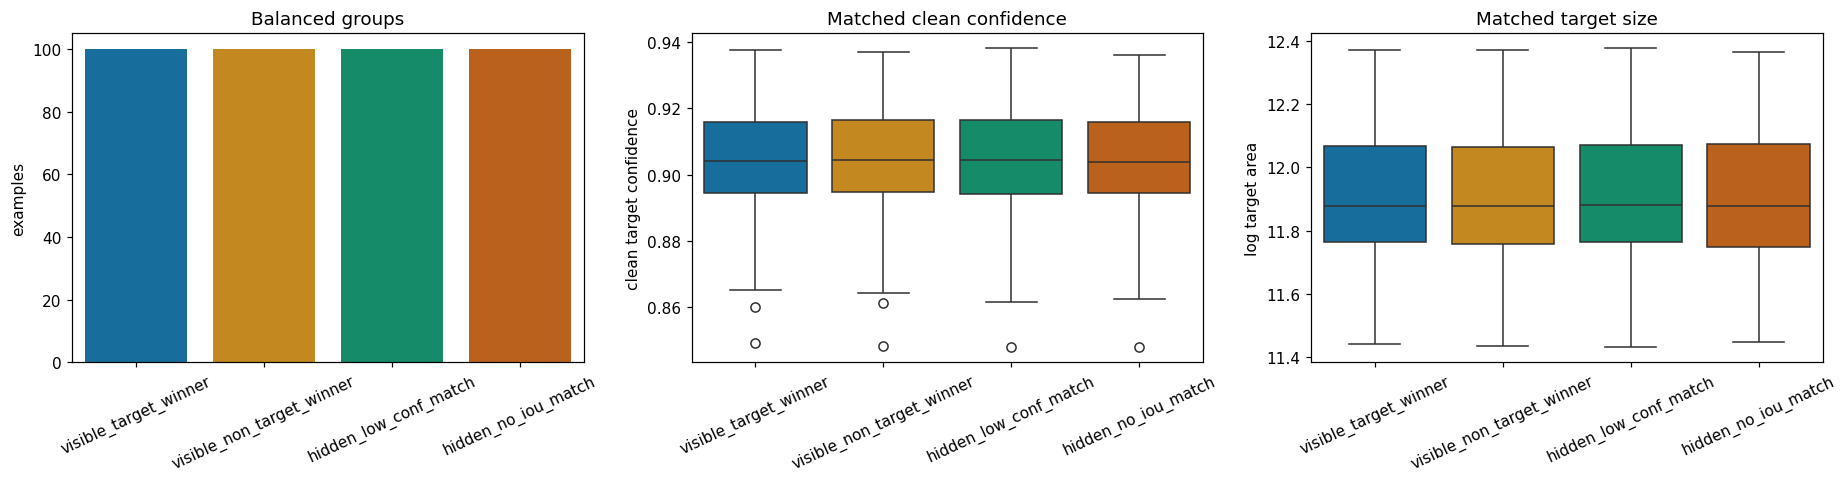

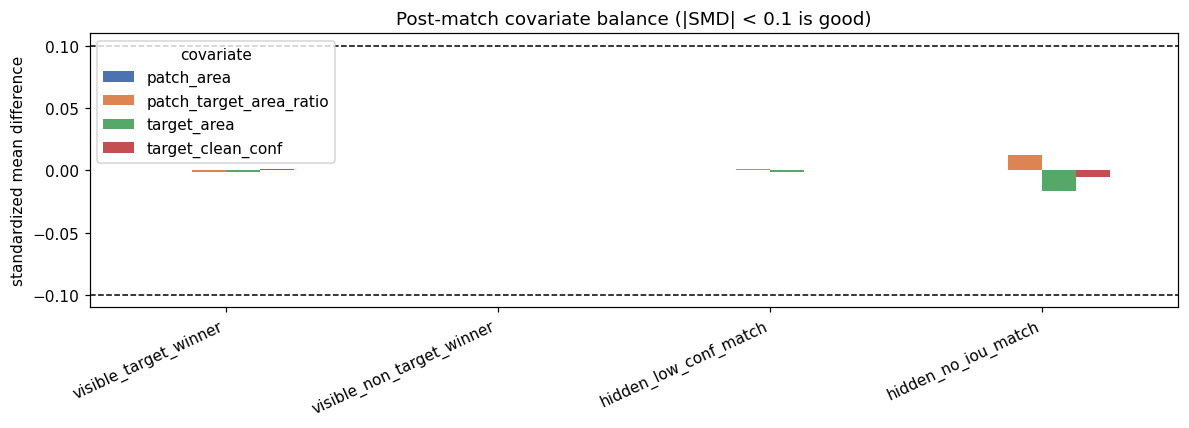

In [14]:
import seaborn as sns

group_colors = dict(zip(GROUP_ORDER, sns.color_palette('colorblind', len(GROUP_ORDER))))
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.countplot(data=balanced_manifest, x='analysis_group', order=GROUP_ORDER, palette=group_colors, hue='analysis_group', legend=False, ax=axes[0])
axes[0].set(title='Balanced groups', xlabel='', ylabel='examples')
sns.boxplot(data=balanced_manifest, x='analysis_group', y='target_clean_conf', order=GROUP_ORDER, palette=group_colors, hue='analysis_group', legend=False, ax=axes[1])
axes[1].set(title='Matched clean confidence', xlabel='', ylabel='clean target confidence')
sns.boxplot(data=balanced_manifest.assign(log_target_area=np.log(balanced_manifest.target_area)), x='analysis_group', y='log_target_area', order=GROUP_ORDER, palette=group_colors, hue='analysis_group', legend=False, ax=axes[2])
axes[2].set(title='Matched target size', xlabel='', ylabel='log target area')
for ax in axes:
    ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

smd = balanced_balance.pivot(index='analysis_group', columns='covariate', values='standardized_mean_difference').reindex(GROUP_ORDER)
ax = smd.plot.bar(figsize=(11, 4), color=sns.color_palette('deep', len(smd.columns)))
ax.axhline(0.1, color='black', linestyle='--', linewidth=1); ax.axhline(-0.1, color='black', linestyle='--', linewidth=1)
ax.set(title='Post-match covariate balance (|SMD| < 0.1 is good)', xlabel='', ylabel='standardized mean difference')
plt.xticks(rotation=25, ha='right'); plt.tight_layout(); plt.show()

In [15]:
balanced_path_config = AttackPathConfig(
    output_dir=str(REPO_ROOT / 'CandidateRoutingAndAttackPath' / 'outputs'),
    max_output_gb=8.0,
    max_examples=None,
    n_steps=BALANCED_N_STEPS,
    alpha_batch_size=4,
    target_kinds=('tracked_clean',),  # primary pre-attack target; no post-selected winner target
    top_contributions=1000,
    visual_map_examples=48,
    selection_seed=BALANCED_SELECTION_SEED,
    selection_manifest=str(balanced_selection.manifest_path),
    progress=True,
)
if RUN_BALANCED_ATTACK_PATH:
    balanced_path_result = run_attack_path_decomposition(
        exp, TRACE_DB, balanced_path_config, force=FORCE_BALANCED_ATTACK_PATH,
    )
    print('attack-path DB:', balanced_path_result.db_path)
    print('digest:', balanced_path_result.digest_path)
else:
    print('Set RUN_BALANCED_ATTACK_PATH=True to run the matched experiment.')

attack-path decomposition:   0%|          | 0/400 [00:00<?, ?img/s]

attack-path DB: /Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/outputs/attack_path_0060cc9878ecdb6e/attack_path.sqlite
digest: /Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/outputs/attack_path_0060cc9878ecdb6e/analysis_digest.md


,target_kind,analysis_group,n,exact_score_delta_mean,exact_score_delta_median,first_order_sum_mean,first_order_sum_median,first_order_residual_mean,first_order_residual_median,total_abs_contribution_mean,total_abs_contribution_median,positive_contribution_mean,positive_contribution_median,negative_contribution_mean,negative_contribution_median,top0p1_abs_fraction_mean,top0p1_abs_fraction_median,top1_abs_fraction_mean,top1_abs_fraction_median,top2_abs_fraction_mean,top2_abs_fraction_median
0,tracked_clean,hidden_low_conf_match,100,-6.424080,-5.660399,-1.602464,-1.599619,-4.821616,-3.994819,24.002699,21.615972,8.788741,7.462767,-15.213958,-13.539443,0.810175,0.806542,1.0,1.0,1.0,1.0
1,tracked_clean,hidden_no_iou_match,100,-7.666877,-8.181321,-1.590696,-1.585600,-6.076181,-6.299200,28.909217,28.962072,10.619218,10.328022,-18.290000,-19.173026,0.809476,0.803747,1.0,1.0,1.0,1.0
2,tracked_clean,visible_non_target_winner,100,-3.367701,-2.579495,-1.089463,-1.122037,-2.278238,-1.578568,13.049203,10.977092,4.840226,4.112320,-8.208976,-6.791743,0.805926,0.802435,1.0,1.0,1.0,1.0
3,tracked_clean,visible_target_winner,100,-3.557203,-2.438089,-0.929334,-0.886620,-2.627870,-1.402848,14.602355,10.757699,5.520843,4.119904,-9.081513,-6.318184,0.799474,0.791733,1.0,1.0,1.0,1.0


,target_kind,left_group,right_group,metric,cohens_d_right_minus_left,mannwhitney_p,holm_p
49,tracked_clean,hidden_low_conf_match,hidden_no_iou_match,positive_contribution,0.434401,0.000826,0.023967
48,tracked_clean,hidden_low_conf_match,hidden_no_iou_match,total_abs_contribution,0.440001,0.003714,0.100265
50,tracked_clean,hidden_low_conf_match,hidden_no_iou_match,negative_contribution,-0.433655,0.009632,0.240798
45,tracked_clean,hidden_low_conf_match,hidden_no_iou_match,exact_score_delta,-0.362241,0.064541,1.000000
46,tracked_clean,hidden_low_conf_match,hidden_no_iou_match,first_order_sum,0.018633,0.857475,1.000000
47,tracked_clean,hidden_low_conf_match,hidden_no_iou_match,first_order_residual,-0.370139,0.070400,1.000000
51,tracked_clean,hidden_low_conf_match,hidden_no_iou_match,top0p1_abs_fraction,-0.028228,0.563358,1.000000
52,tracked_clean,hidden_low_conf_match,hidden_no_iou_match,top1_abs_fraction,-0.123816,0.336711,1.000000
53,tracked_clean,hidden_low_conf_match,hidden_no_iou_match,top2_abs_fraction,-0.074339,0.472521,1.000000


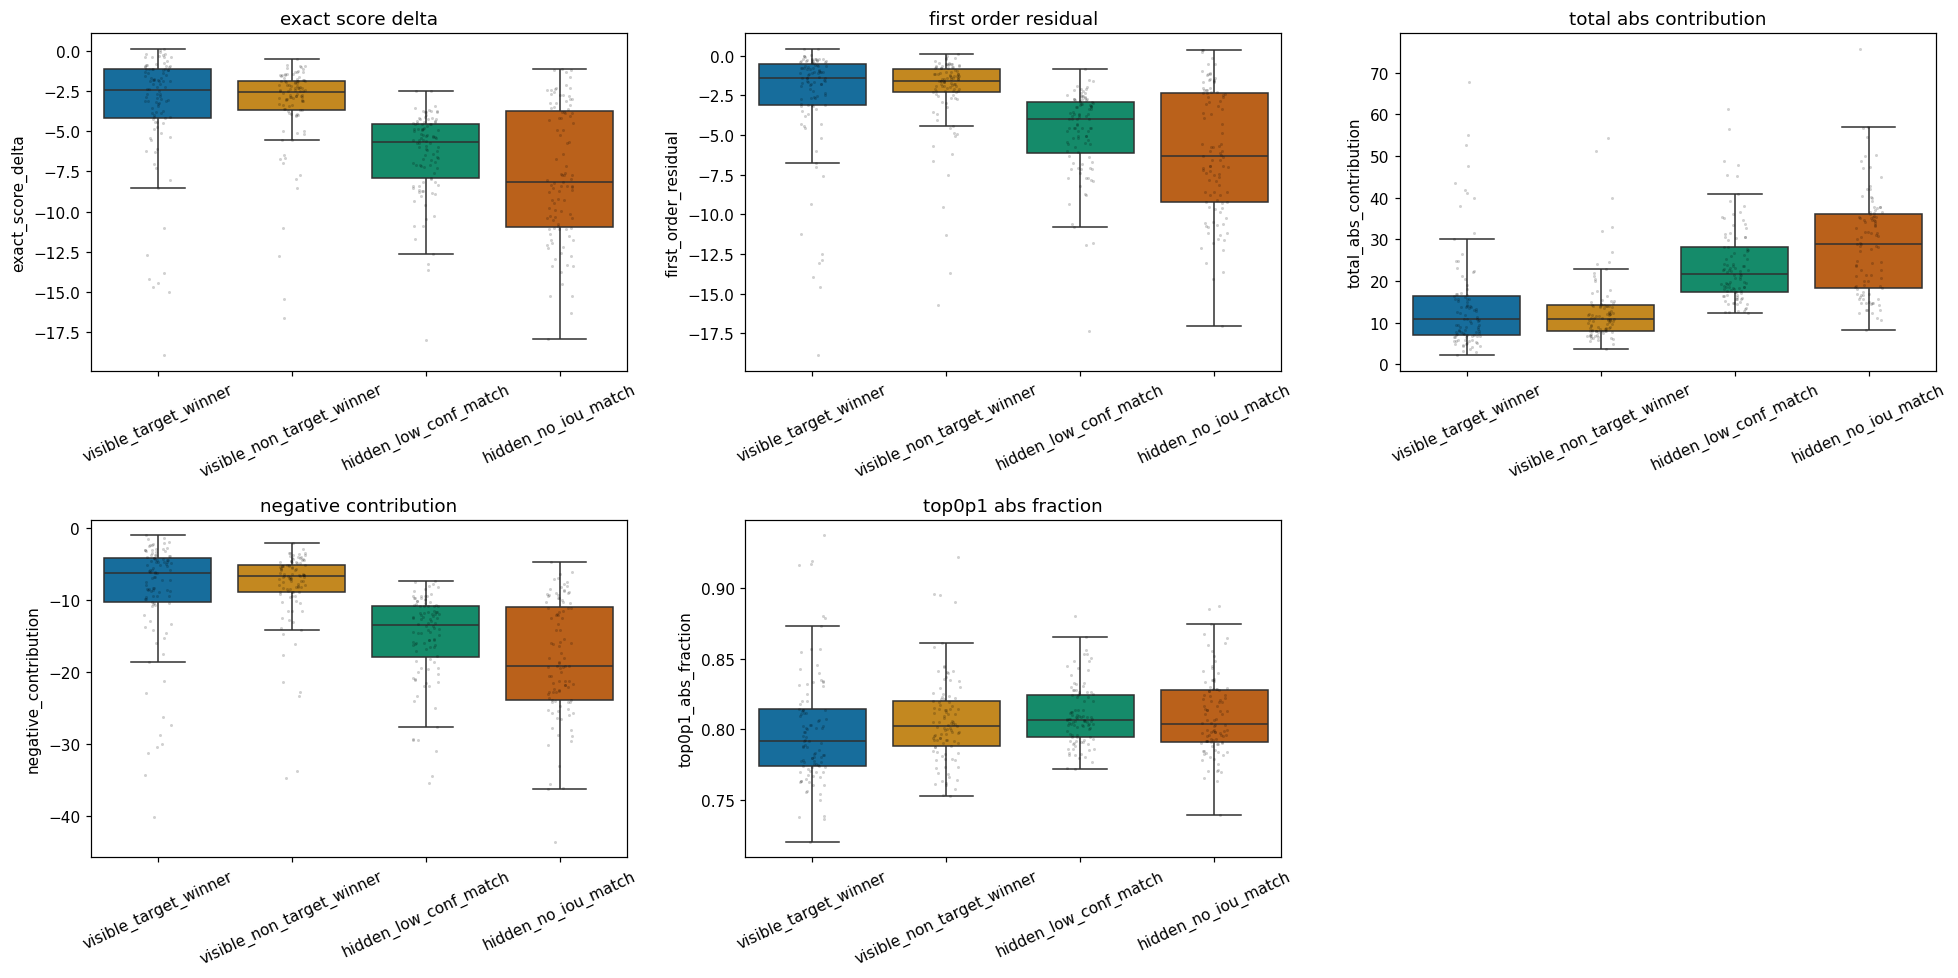

Token-efficient outputs:
  group_summary: /Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/outputs/attack_path_0060cc9878ecdb6e/balanced_target_analysis/balanced_attack_path_group_summary.csv
  pairwise: /Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/outputs/attack_path_0060cc9878ecdb6e/balanced_target_analysis/balanced_attack_path_pairwise.csv
  digest: /Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/outputs/attack_path_0060cc9878ecdb6e/balanced_target_analysis/analysis_digest.md


In [16]:
balanced_result_dir = balanced_path_result.run_dir / 'balanced_target_analysis'
balanced_artifacts = summarize_balanced_attack_path(balanced_path_result.db_path, balanced_result_dir)
balanced_tables = load_attack_path_tables(balanced_path_result)
balanced_examples = balanced_tables['examples'].rename(columns={'mechanism_mode': 'analysis_group'})
balanced_group_summary = pd.read_csv(balanced_artifacts['group_summary'])
balanced_pairwise = pd.read_csv(balanced_artifacts['pairwise'])
display(balanced_group_summary)
display(balanced_pairwise.query("left_group == 'hidden_low_conf_match' and right_group == 'hidden_no_iou_match'").sort_values('holm_p'))

plot_metrics = ['exact_score_delta', 'first_order_residual', 'total_abs_contribution', 'negative_contribution', 'top0p1_abs_fraction']
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, metric in zip(axes.flat, plot_metrics):
    sns.boxplot(data=balanced_examples, x='analysis_group', y=metric, order=GROUP_ORDER, palette=group_colors, hue='analysis_group', legend=False, showfliers=False, ax=ax)
    sns.stripplot(data=balanced_examples, x='analysis_group', y=metric, order=GROUP_ORDER, color='black', alpha=.18, size=2, ax=ax)
    ax.set(title=metric.replace('_', ' '), xlabel='')
    ax.tick_params(axis='x', rotation=25)
axes.flat[-1].axis('off')
plt.tight_layout(); plt.show()

print('Token-efficient outputs:')
for name, path in balanced_artifacts.items():
    print(f'  {name}: {path}')

## 7. Sign-selective causal repair

Здесь path attribution проверяется интервенцией. На patched-входе Detect head отдельные координаты возвращаются к clean-значениям. Основная стратегия — `top_negative`: компоненты с наиболее сильным отрицательным signed contribution для фиксированного clean target. Контроли: `top_positive`, `top_abs`, крупнейшие activation delta и случайные координаты с похожей величиной delta.

Primary endpoint — восстановление того же target после NMS при `IoU >= 0.5` и `confidence >= 0.25`. Дополнительно отдельно смотрим fixed-cell logit, confidence и maximum IoU. Сравнения при `k <= 250` имеют одинаковый intervention budget; `k=500/1000` нужны как saturation doses, потому что знаковых top-компонентов иногда меньше запрошенного числа.

In [ ]:
from CandidateRoutingAndAttackPath.causal_repair import (
    CausalRepairConfig, load_causal_repair, run_causal_repair,
)

REPAIR_ATTACK_PATH_DB = REPO_ROOT / 'CandidateRoutingAndAttackPath' / 'outputs' / 'attack_path_0060cc9878ecdb6e' / 'attack_path.sqlite'
REPAIR_MANIFEST = balanced_selection.manifest_path
RUN_CAUSAL_REPAIR = True
FORCE_CAUSAL_REPAIR = False

repair_config = CausalRepairConfig(
    output_dir=str(REPO_ROOT / 'CandidateRoutingAndAttackPath' / 'outputs'),
    max_output_gb=8.0,
    max_examples=None,                  # все 400 matched examples
    k_values=(10, 50, 100, 250, 500, 1000),
    random_repeats=3,
    forward_batch_size=8,
    detection_conf=DETECTION_CONF,
    match_iou=MATCH_IOU,
    seed=53,
    progress=True,
)
display(pd.Series(repair_config.__dict__ if hasattr(repair_config, '__dict__') else {name: getattr(repair_config, name) for name in repair_config.__slots__}).to_frame('value'))

In [ ]:
if RUN_CAUSAL_REPAIR:
    repair_result = run_causal_repair(
        exp, REPAIR_ATTACK_PATH_DB, TRACE_DB, REPAIR_MANIFEST,
        repair_config, force=FORCE_CAUSAL_REPAIR,
    )
    print('repair DB:', repair_result.db_path)
    print('short summary:', repair_result.group_summary_path)
    print('digest:', repair_result.digest_path)
else:
    print('Set RUN_CAUSAL_REPAIR=True to run the resumable intervention experiment.')

In [ ]:
repair = load_causal_repair(repair_result)
repair_summary = pd.read_csv(repair_result.group_summary_path)
display(pd.read_json(repair_result.summary_path, typ='series').to_frame('value'))

# Random repeats сначала усредняются внутри example: единицей анализа остается изображение.
repair_unit = (repair.groupby(
    ['example_id', 'analysis_group', 'match_set', 'strategy', 'k_requested'], as_index=False
).agg(
    actual_k=('actual_k', 'mean'),
    target_logit_gain=('target_logit_gain', 'mean'),
    target_conf_gain=('target_conf_gain', 'mean'),
    target_iou_gain=('target_iou_gain', 'mean'),
    fixed_target_logit=('fixed_target_logit', 'mean'),
    target_match_conf=('target_match_conf', 'mean'),
    target_max_iou=('target_max_iou', 'mean'),
    target_detected=('target_detected', 'mean'),
    restored_delta_l1=('restored_delta_l1', 'mean'),
))

baseline = repair_unit.query("strategy == 'patched'").copy()
baseline['expected_detected'] = (~baseline.analysis_group.str.startswith('hidden')).astype(int)
display(pd.crosstab(baseline.expected_detected, baseline.target_detected, rownames=['expected'], colnames=['recomputed']))
display(repair_summary.head(80))

In [ ]:
dose = repair_unit.query("k_requested > 0").copy()
strategy_order = ['top_negative', 'top_abs', 'top_positive', 'delta_magnitude', 'random_delta_matched']
strategy_colors = dict(zip(strategy_order, sns.color_palette('colorblind', len(strategy_order))))
hidden_order = ['hidden_low_conf_match', 'hidden_no_iou_match']

fig, axes = plt.subplots(2, 3, figsize=(19, 10))
outcomes = [
    ('target_logit_gain', 'Fixed target logit gain'),
    ('target_match_conf', 'Post-NMS target confidence'),
    ('target_max_iou', 'Maximum IoU with clean target'),
    ('target_detected', 'Target rescue rate'),
    ('restored_delta_l1', 'Restored activation |delta|'),
]
for ax, (metric, title) in zip(axes.flat, outcomes):
    sns.lineplot(
        data=dose[dose.analysis_group.isin(hidden_order)], x='k_requested', y=metric,
        hue='strategy', style='analysis_group', hue_order=strategy_order, style_order=hidden_order,
        palette=strategy_colors, markers=True, dashes=True, errorbar=('ci', 95), ax=ax,
    )
    ax.set(title=title, xlabel='restored coordinates (requested k)')
    if metric != 'target_logit_gain': ax.get_legend().remove()
axes.flat[-1].axis('off')
plt.tight_layout(); plt.show()

oracle = repair_unit[repair_unit.strategy.isin(['patched', 'oracle_target_level', 'oracle_full_head'])]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, metric in zip(axes, ['fixed_target_logit', 'target_match_conf', 'target_max_iou']):
    sns.barplot(data=oracle, x='analysis_group', y=metric, hue='strategy', order=GROUP_ORDER, errorbar=('ci', 95), ax=ax)
    ax.set(title=f'Patched baseline and clean-head ceiling: {metric}', xlabel='')
    ax.tick_params(axis='x', rotation=25)
plt.tight_layout(); plt.show()

primary = dose.query("k_requested <= 250 and strategy in ['top_negative', 'top_positive', 'delta_magnitude', 'random_delta_matched']")
display(primary.groupby(['analysis_group', 'strategy', 'k_requested']).agg(
    n=('example_id', 'nunique'), mean_logit_gain=('target_logit_gain', 'mean'),
    mean_conf=('target_match_conf', 'mean'), mean_max_iou=('target_max_iou', 'mean'),
    rescue_rate=('target_detected', 'mean'), mean_actual_k=('actual_k', 'mean'),
).reset_index())